In [1]:
print('Hi')

Hi


In [2]:
print('By')

By


In [1]:
# pandas
# tensoflow
# matplotlib
# seaborn
# scikit-learn
# flask

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
import seaborn as sns
import cv2
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
path=r'.\PlantVillage'

In [3]:
from pathlib import Path

In [4]:
win_path=Path(path)

In [5]:
win_path

WindowsPath('PlantVillage')

In [6]:
all_images=list(win_path.glob('*/*.jpg'))

In [7]:
len(all_images)

2150

In [8]:
datagen=ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,     # 80% train, 20% validation
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True)

In [9]:
train_data=datagen.flow_from_directory(path,
                           target_size=(224,224),
                           batch_size=32,
                           shuffle=True,
                           class_mode='categorical',
                           subset='training')

Found 1725 images belonging to 3 classes.


In [20]:
test_data=datagen.flow_from_directory(path,
                           target_size=(224,224),
                           batch_size=32,
                           shuffle=False,
                           class_mode='categorical',
                           subset='validation')

Found 430 images belonging to 3 classes.


In [10]:
class_names=list(train_data.class_indices.keys())

Potato___Early_blight


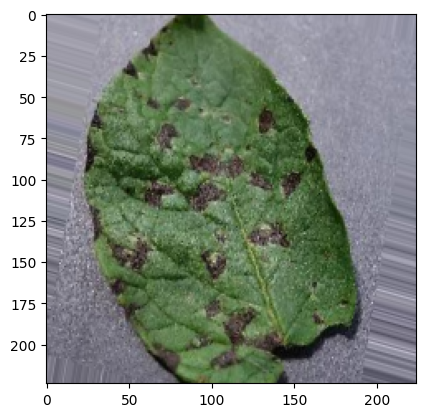

In [11]:
for i,j in train_data:
    plt.imshow(i[0])
    print(class_names[np.argmax(j[0])])
    break

In [12]:
s1=pd.Series(train_data.classes)

In [13]:
from tensorflow.keras.applications import VGG16,VGG19

In [14]:
base_model = VGG19(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

In [15]:
# 16 layers >> Freeze 
# Why freeze
# We only want to train our new classification layers(fully connected layers)
# We don’t want to re-train the pre-trained knowledge

In [16]:
for layer in base_model.layers:
    layer.trainable = False

In [17]:
final_model=keras.Sequential([
       base_model,
       Flatten(),
       Dense(128,activation='relu'),
       Dropout(0.3),
       Dense(64,activation='relu'),
       Dropout(0.3),
       Dense(3,activation='softmax')
])

In [18]:
final_model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [21]:
final_model.fit(
    train_data,
    epochs=2,
    validation_data=test_data   
)

Epoch 1/2
54/54 ━━━━━━━━━━━━━━━━━━━━ 760s 14s/step - accuracy: 0.6516 - loss: 1.1130 - val_accuracy: 0.8767 - val_loss: 0.3907
Epoch 2/2
54/54 ━━━━━━━━━━━━━━━━━━━━ 822s 14s/step - accuracy: 0.8319 - loss: 0.4494 - val_accuracy: 0.8977 - val_loss: 0.2854


In [ ]:
final_model.evaluate(test_data)

In [ ]:
y_pred=final_model.predict(test_data)
y_pred1=[  np.argmax(i) for i in y_pred]

In [ ]:
y_test=test_data.classes

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report

In [ ]:
confusion_matrix(y_test,y_pred1)

In [ ]:
print(classification_report(y_test,y_pred1))

In [22]:
final_model.save('vgg19_potato.keras')

In [ ]:
# new image

In [ ]:
from tensorflow.keras.preprocessing.image import load_img,img_to_array
path=r'C:\Users\Admin\Desktop\dm.jpg'
img1=load_img(path,target_size=(224,224))
img2 = img_to_array(img1)
img3 = img2/ 255.0
img4 = np.expand_dims(img3, axis=0)
class_names[np.argmax(final_model.predict(img4))]